In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
df = pd.read_csv('2015.csv')
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [6]:
df.shape

(158, 12)

In [7]:
df.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [8]:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [9]:
df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


### Which are the Top 10 happiest countries? 

In [10]:
df.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score']]

,Country,Happiness Score
0,Switzerland,7.587
1,Iceland,7.561
2,Denmark,7.527
3,Norway,7.522
4,Canada,7.427
5,Finland,7.406
6,Netherlands,7.378
7,Sweden,7.364
8,New Zealand,7.286
9,Australia,7.284


### Which are the Bottom 10 least happy countries?

In [11]:
df.nsmallest(10, 'Happiness Score')[['Country','Happiness Score']]

,Country,Happiness Score
157,Togo,2.839
156,Burundi,2.905
155,Syria,3.006
154,Benin,3.340
153,Rwanda,3.465
152,Afghanistan,3.575
151,Burkina Faso,3.587
150,Ivory Coast,3.655
149,Guinea,3.656
148,Chad,3.667


### Which region has the highest average happiness score? 

In [25]:
df.groupby('Region')['Happiness Score'].mean().idxmax()

Region
Australia and New Zealand          7.285000
Central and Eastern Europe         5.332931
Eastern Asia                       5.626167
Latin America and Caribbean        6.144682
Middle East and Northern Africa    5.406900
North America                      7.273000
Southeastern Asia                  5.317444
Southern Asia                      4.580857
Sub-Saharan Africa                 4.202800
Western Europe                     6.689619
Name: Happiness Score, dtype: float64

### Plot a bar chart of average happiness score by region 

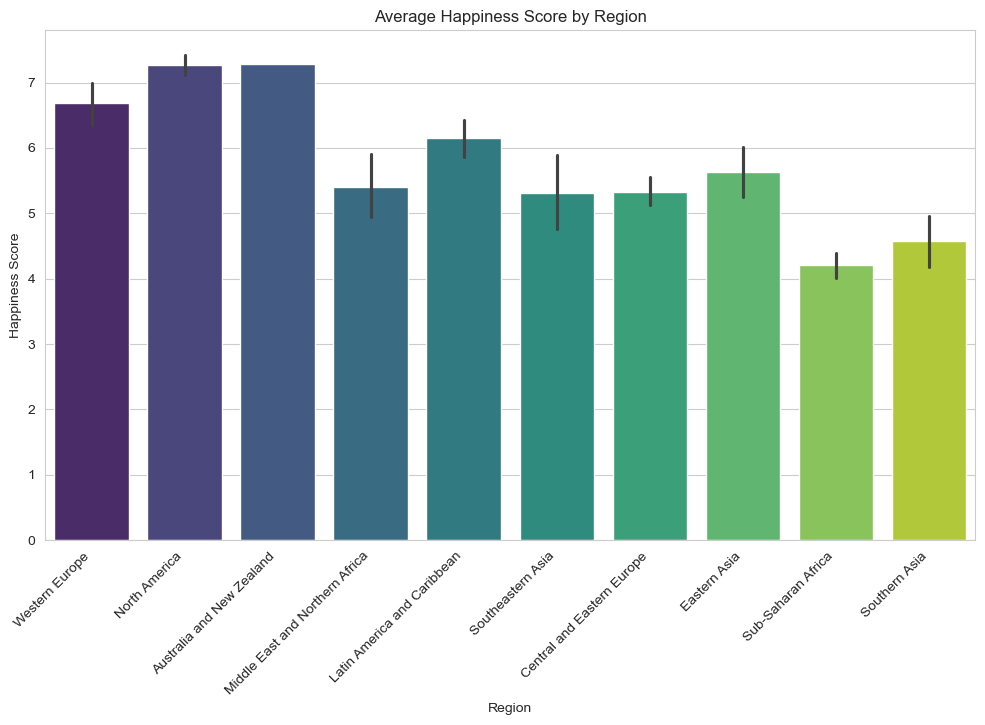

In [13]:
sns.barplot(data=df, x='Region', y='Happiness Score', estimator='mean', palette='viridis')
plt.title("Average Happiness Score by Region")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

### Distribution of Happiness Scores — is it normally distributed?

Text(0.5, 1.0, 'Distribution of Happiness Scores')

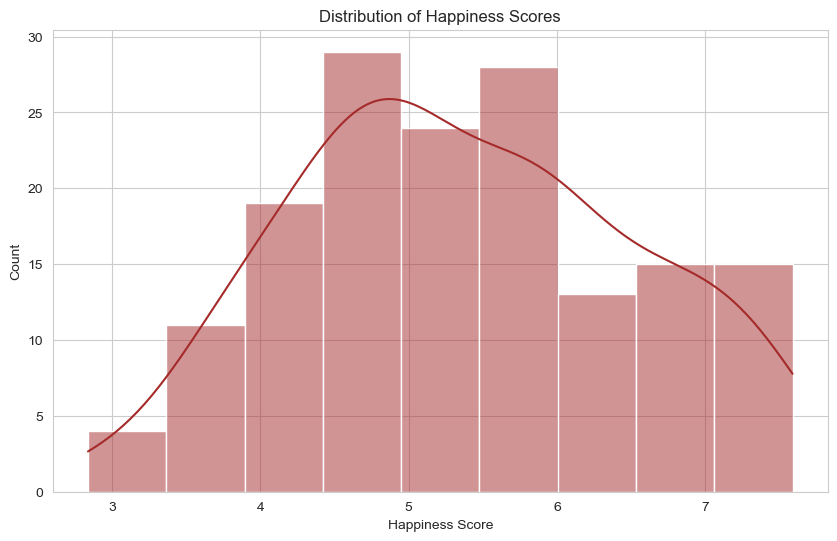

In [14]:
sns.histplot(df['Happiness Score'], kde=True, color='brown')
plt.title('Distribution of Happiness Scores')

### Top 10 countries by GDP per Capita 

In [15]:
df.nlargest(10, 'Economy (GDP per Capita)')[['Country','Economy (GDP per Capita)']]

,Country,Economy (GDP per Capita)
27,Qatar,1.69042
16,Luxembourg,1.56391
38,Kuwait,1.55422
23,Singapore,1.52186
3,Norway,1.45900
19,United Arab Emirates,1.42727
0,Switzerland,1.39651
34,Saudi Arabia,1.39541
14,United States,1.39451
71,Hong Kong,1.38604


### Correlation between GDP and Happiness Score 

In [16]:
df[['Economy (GDP per Capita)', 'Happiness Score']].corr()

,Economy (GDP per Capita),Happiness Score
Economy (GDP per Capita),1.000000,0.780966
Happiness Score,0.780966,1.000000


### Scatter plot — GDP vs Happiness Score 

Text(0.5, 1.0, 'GDP vs Happiness Score')

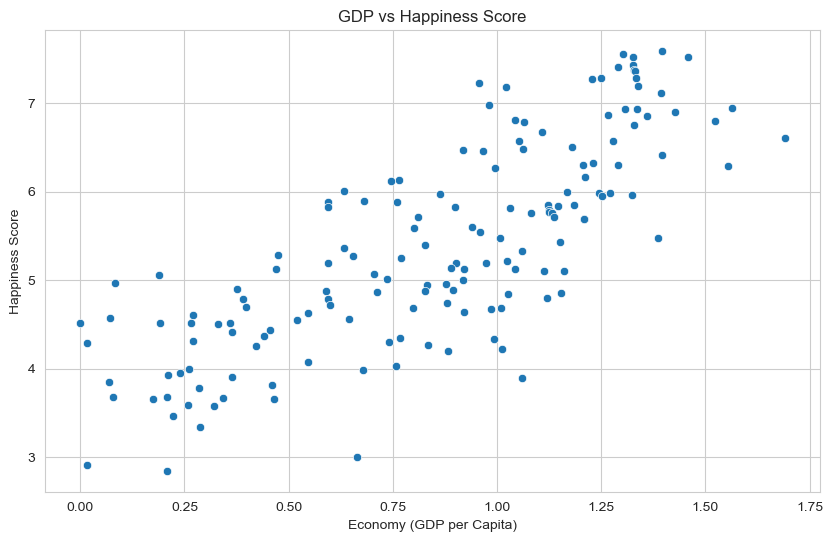

In [17]:
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score')
plt.title('GDP vs Happiness Score')

### Visualize correlation matrix with heatmap

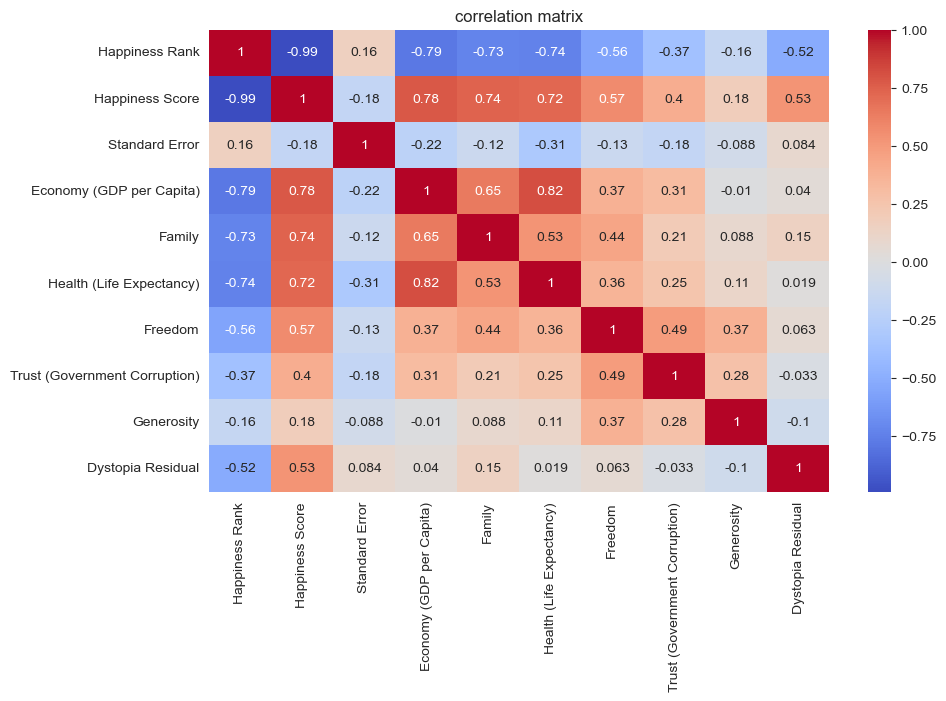

In [18]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

###  Is the correlation between GDP and Happiness Score statistically significant? 

In [19]:
corr, p_value = stats.pearsonr(df['Economy (GDP per Capita)'], df['Happiness Score'])
print(f'corr is {corr} and p_value is {p_value}')

corr is 0.7809655268660214 and p_value is 1.0505384131958939e-33


In [20]:
alpha = 0.05
if p_value < alpha:
    print('Reject null hypothesis, Correlation is statistically significant')
else:
    print('Fail to reject null hypothesis, Correlation is not statistically significant')

Reject null hypothesis, Correlation is statistically significant


### Box plot — Happiness Score by Region

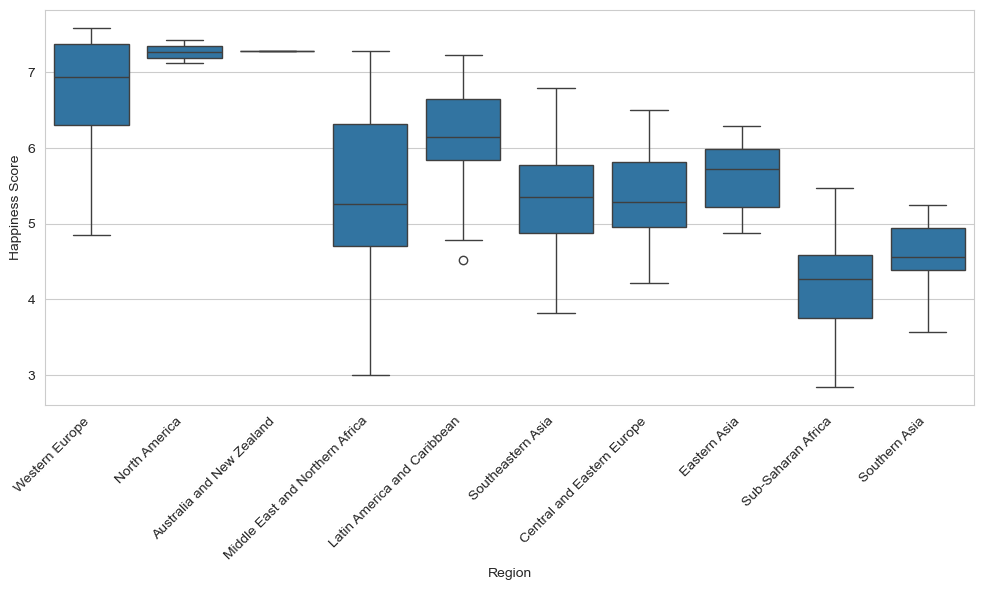

In [112]:
sns.boxplot(data=df, x='Region', y='Happiness Score')
plt.xticks(rotation = 45, ha='right')
plt.tight_layout()
plt.show()

### Which factor correlates most with Happiness Score? 

In [20]:
happiness_corr = corr_matrix['Happiness Score']
topcorr = happiness_corr.drop('Happiness Score')
topcorr.idxmax()

'Economy (GDP per Capita)'

### happiness scores of Western Europe vs Sub-Saharan Africa — are they statistically different? 

In [21]:
we = df[df['Region'] == 'Western Europe']['Happiness Score']
ssa = df[df['Region'] == 'Sub-Saharan Africa']['Happiness Score']

t_stat, p_value = stats.ttest_ind(we, ssa)
print(f't_stat: {t_stat}, p_value: {p_value}')

t_stat: 13.374348124815134, p_value: 1.6300382933859878e-19


In [22]:
alpha = 0.05
if p_value < alpha:
    print('Reject null hypothesis, they are statistically different')
else:
    print('Fail to reject null hypothesis, they are not statistically different')

Reject null hypothesis, they are statistically different


## Multi-year trend analysis:

In [22]:
dfs = []

for year in range(2015, 2023):
    df_temp = pd.read_csv(f'{year}.csv')
    
    # Rename columns to standard names
    rename_map = {
        # Country
        'Country or region': 'Country',
        'Country name': 'Country',
        
        # Happiness Score
        'Happiness.Score': 'Happiness Score',
        'Score': 'Happiness Score',
        'Ladder score': 'Happiness Score',
        'Happiness score': 'Happiness Score',
        
        # GDP
        'Economy..GDP.per.Capita.': 'GDP',
        'Economy (GDP per Capita)': 'GDP',
        'GDP per capita': 'GDP',
        'Logged GDP per capita': 'GDP',
        'Explained by: GDP per capita': 'GDP',
        
        # Health
        'Health (Life Expectancy)': 'Health',
        'Health..Life.Expectancy.': 'Health',
        'Healthy life expectancy': 'Health',
        
        # Freedom
        'Freedom to make life choices': 'Freedom',
        
        # Corruption
        'Trust (Government Corruption)': 'Corruption',
        'Trust..Government.Corruption.': 'Corruption',
        'Perceptions of corruption': 'Corruption',
    }
    
    df_temp = df_temp.rename(columns=rename_map)
    df_temp['Year'] = year
    
    # Keep only common columns
    keep_cols = ['Country', 'Happiness Score', 'GDP', 'Health', 'Freedom', 'Generosity', 'Corruption', 'Year']
    
    # Only keep columns that exist
    keep_cols = [c for c in keep_cols if c in df_temp.columns]
    df_temp = df_temp[keep_cols]
    
    dfs.append(df_temp)
    print(f"{year}: {df_temp.shape}")

# Combine all years
df_all = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset: {df_all.shape}")
df_all.head()

2015: (158, 8)
2016: (157, 8)
2017: (155, 8)
2018: (156, 8)
2019: (156, 8)
2020: (153, 8)
2021: (149, 8)
2022: (147, 4)

Combined dataset: (1231, 8)


,Country,Happiness Score,GDP,Health,Freedom,Generosity,Corruption,Year
0,Switzerland,7.587,1.39651,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,7.561,1.30232,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,7.527,1.32548,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,7.522,1.459,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,7.427,1.32629,0.90563,0.63297,0.45811,0.32957,2015


In [27]:
df_all.dtypes

Country             object
Happiness Score     object
GDP                 object
Health             float64
Freedom            float64
Generosity         float64
Corruption         float64
Year                 int64
dtype: object

In [29]:
numeric_cols = [
    'Happiness Score',
    'GDP',
    'Health',
    'Freedom',
    'Generosity',
    'Corruption'
]
for col in numeric_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

In [30]:
df_all.dtypes

Country             object
Happiness Score    float64
GDP                float64
Health             float64
Freedom            float64
Generosity         float64
Corruption         float64
Year                 int64
dtype: object

In [93]:
df_all.isna().sum()

Country              0
Happiness Score    147
GDP                147
Health             147
Freedom            147
Generosity         147
Corruption         148
Year                 0
dtype: int64

In [96]:
df_all=df_all.dropna()
df_all.isna().sum()

Country            0
Happiness Score    0
GDP                0
Health             0
Freedom            0
Generosity         0
Corruption         0
Year               0
dtype: int64

### Average global happiness score per year

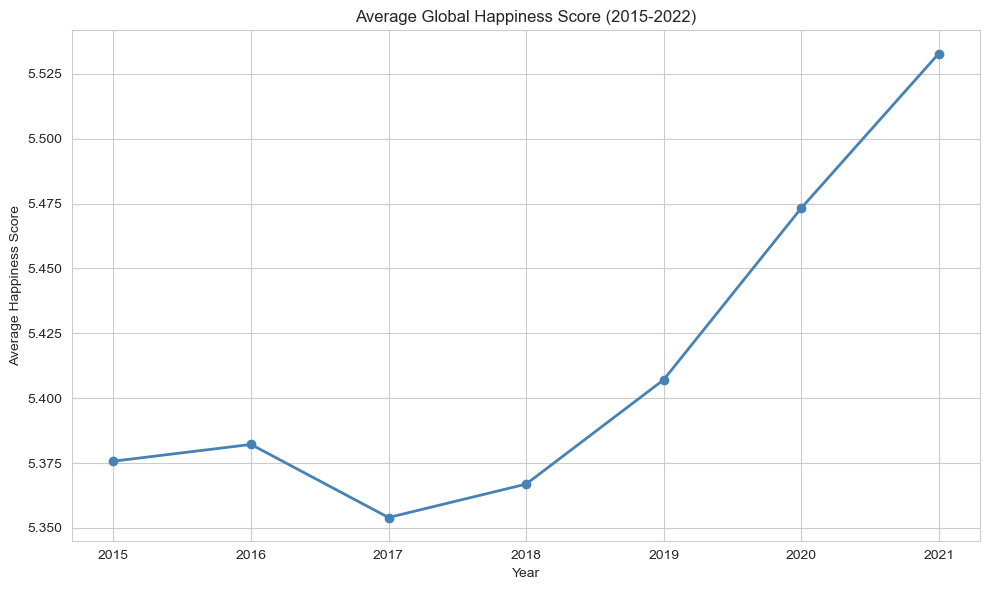

In [97]:
yearly_avg = df_all.groupby('Year')['Happiness Score'].mean()

plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='steelblue', linewidth=2)
plt.title('Average Global Happiness Score (2015-2022)')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')
plt.xticks(range(2015, 2022))
plt.tight_layout()
plt.show()

### Which country appeared in the top 5 most consistently across all years?

In [98]:
top5_per_year = df_all.groupby('Year').apply(
    lambda x: x.nlargest(5, 'Happiness Score')['Country']
).reset_index()

top5_per_year['Country'].value_counts().head(10)

Country
Iceland        7
Denmark        7
Switzerland    6
Norway         6
Finland        6
Netherlands    2
Canada         1
Name: count, dtype: int64

### How has average GDP changed over the years?

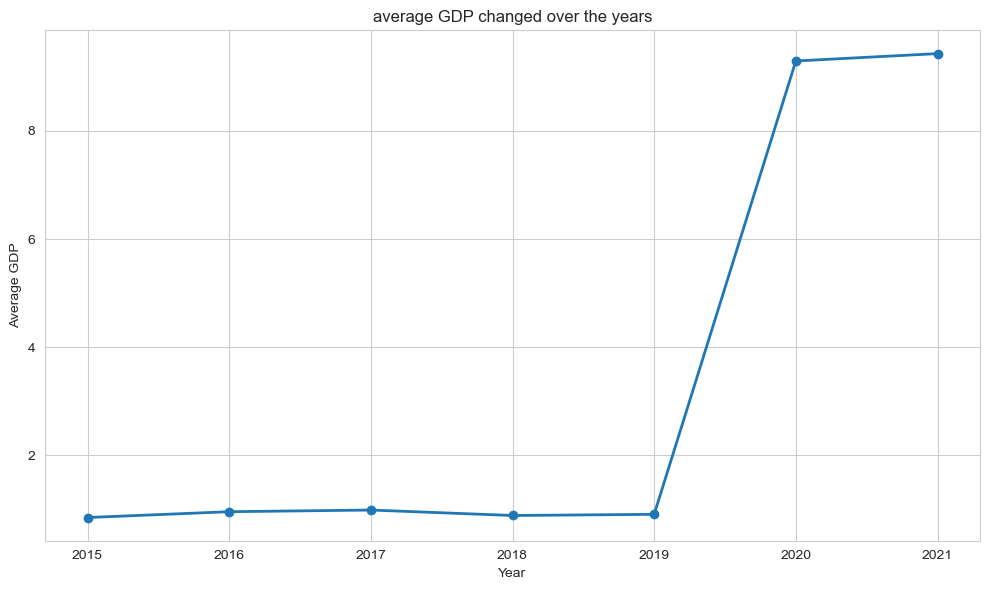

In [104]:
yearly_GDP = df_all.groupby('Year')['GDP'].mean()
plt.plot(yearly_GDP.index, yearly_GDP.values, marker='o', linewidth=2)
plt.title('average GDP changed over the years')
plt.xlabel('Year')
plt.ylabel('Average GDP')
plt.xticks(range(2015,2022))
plt.tight_layout()
plt.show()

## Key Findings 

- Western Europe had the highest median happiness score across regions based on the 2015 boxplot analysis, while Australia and New Zealand had the highest average score but only includes 2 countries.
- Correlation between GDP and Happiness is 0.78 — it means Richest Countries tend to have happier citizens however this does not mean wealth causes happiness.
- Iceland and Denmark each appeared in the top 5 happiest countries across all 7 years with valid happiness data (2015-2021), as 2022 lacked complete score data.
- Western Europe and Sub-Saharan Africa have statistically significantly different happiness scores (t-stat = 13.37, p-value ≈ 0), confirming the happiness gap between these regions is not due to chance.
- Global happiness between 2015-2021 — increased from 5.37 in 2015 to 5.53 in 2021 — a modest but consistent upward trend suggesting gradual improvement in global wellbeing despite economic and political challenges.